In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('/Users/eri/Desktop/youtube_videos.csv')


print(df.shape)      
df.head()            

(210, 18)


,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [5]:
scaler = MinMaxScaler()

df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

df["subscribers_minmax"]

0      0.056122
1      0.002541
2      0.308431
3      0.063485
4      0.003147
         ...   
205    0.001006
206    0.000565
207    0.061652
208    0.000814
209    0.070625
Name: subscribers_minmax, Length: 210, dtype: float64

In [6]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

In [8]:
standard_scaler = StandardScaler()
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [9]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

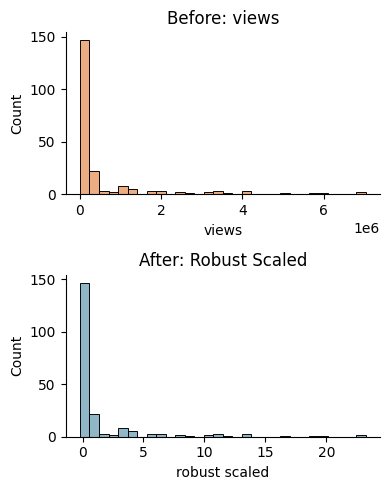

In [12]:
scaler = RobustScaler()
df["views_robust"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

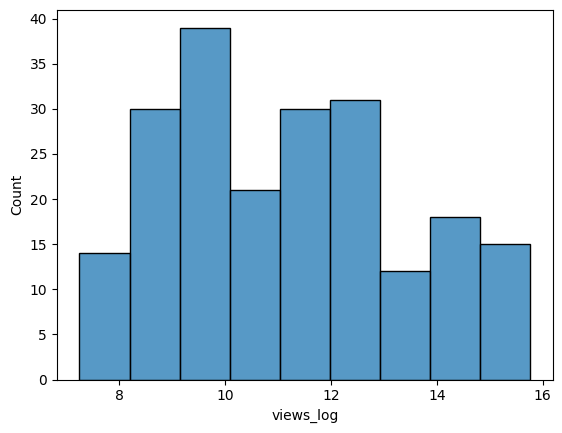

In [13]:
import numpy as np

df["views_log"] = np.log1p(df["views"])
sns.histplot(df["views_log"])
plt.show()

In [14]:
bins = [0, 300, 2000, float("inf")]
labels = ['short', "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

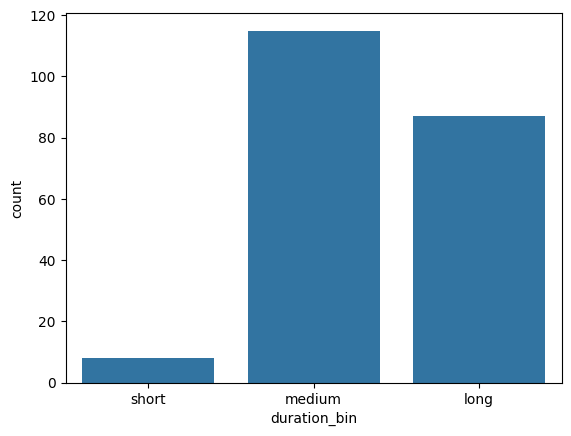

In [15]:
sns.countplot(data=df, x="duration_bin", order=["short", "medium", "long"])
plt.show()

In [18]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]])

In [19]:
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1.0
1,Small,0.0
2,Large,2.0
3,Mid,1.0
4,Small,0.0
...,...,...
205,Small,0.0
206,Small,0.0
207,Mid,1.0
208,Small,0.0


In [21]:
dummyVars = pd.get_dummies(df["category"], prefix="is")
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [22]:
df = pd.concat([df, dummyVars], axis=1)

In [23]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [24]:
import numpy as np

day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [25]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[ns]

In [26]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [29]:
def countCaps(t):
    return sum(1 for w in t.split() if w[0].isupper())

df["caps_count"] = df["title"].apply(countCaps)

df["caps_count"]


0      3
1      2
2      1
3      2
4      4
      ..
205    4
206    2
207    2
208    3
209    3
Name: caps_count, Length: 210, dtype: int64

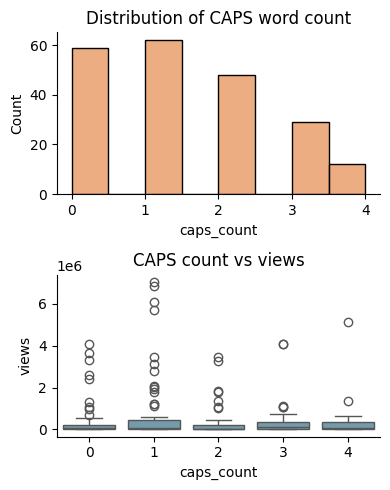

In [31]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["caps_count"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df,
            x="caps_count",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

sns.despine()
plt.tight_layout()
plt.show()

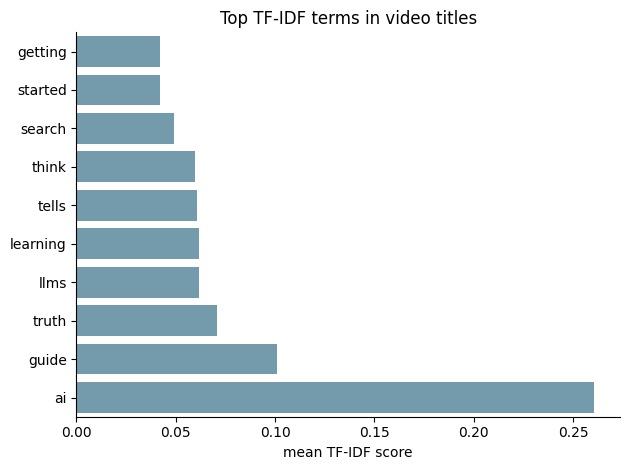

In [33]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

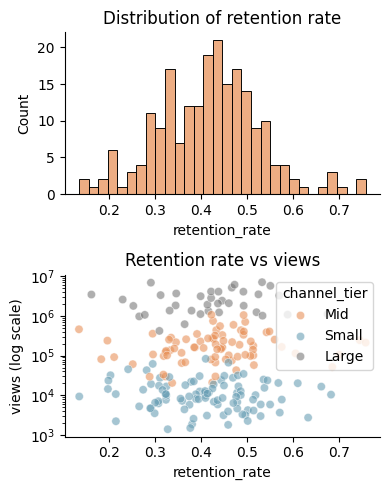

In [34]:


df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_minutes"])
).clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

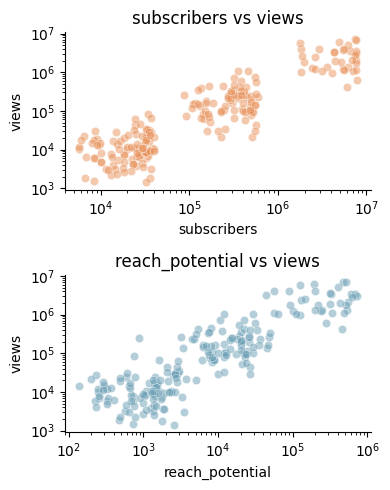

In [35]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)
result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
